# Taller análisis descriptivo de variables cualitativas

Se va a trabajar con un dataset que contiene información sobre incidentes de tránsito en Medellín con víctimas.

Cárguelo y verifique que se haya cargado correctamente.

# **Carga del Dataset**

In [83]:
import pandas as pd

df = pd.read_csv("/content/Accidentes de tránsito en Medellín.csv")
df.head()

,Fecha_incidente,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Barrio,Dia_semana,Mes,Año
0,2014-01-01,Heridos,Otro,M,Motociclista,10 - 19,04 - Aranjuez,Manrique Central No. 1,Miércoles,Enero,2014
1,2014-01-01,Heridos,Atropello,M,Motociclista,20 - 29,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
2,2014-01-01,Heridos,Atropello,F,Peatón,10 - 19,01 - Popular,Moscú No. 2,Miércoles,Enero,2014
3,2014-01-01,Heridos,Atropello,M,Motociclista,10 - 19,16 - Belén,Las Mercedes,Miércoles,Enero,2014
4,2014-01-01,Heridos,Atropello,M,Peatón,30 - 39,16 - Belén,Las Mercedes,Miércoles,Enero,2014


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235843 entries, 0 to 235842
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Fecha_incidente   235843 non-null  object
 1   Gravedad_victima  235843 non-null  object
 2   Clase_incidente   235843 non-null  object
 3   Sexo              233366 non-null  object
 4   Condicion         235843 non-null  object
 5   Grupo_edad        233309 non-null  object
 6   Comuna            214117 non-null  object
 7   Barrio            213961 non-null  object
 8   Dia_semana        235843 non-null  object
 9   Mes               235843 non-null  object
 10  Año               235843 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 19.8+ MB


# **Conversión de fecha y exclusión del año 2021**

La variable "Fecha_incidente" debe convertirse a dato de tiempo.

Excluya los datos del año 2021.

In [85]:
df['Fecha_incidente'] = pd.to_datetime(
    df['Fecha_incidente'],
    )
df.info()

df = df[df["Fecha_incidente"].dt.year != 2021]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235843 entries, 0 to 235842
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Fecha_incidente   235843 non-null  datetime64[ns]
 1   Gravedad_victima  235843 non-null  object        
 2   Clase_incidente   235843 non-null  object        
 3   Sexo              233366 non-null  object        
 4   Condicion         235843 non-null  object        
 5   Grupo_edad        233309 non-null  object        
 6   Comuna            214117 non-null  object        
 7   Barrio            213961 non-null  object        
 8   Dia_semana        235843 non-null  object        
 9   Mes               235843 non-null  object        
 10  Año               235843 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 19.8+ MB


# **Identificación Tipos de Variables**

De acuerdo a lo visto en clase, indique qué tipo de variable es cada una de las que están en el DataFrame.

Convierta a "category" las variables categóricas, cuidando que las variables nominales y ordinales queden correctamente convertidas.

- **Fecha_incidente ->** Cuantitativa, continua de intervalo
- **Gravedad_victima** -> Cualitativa, nominal
- **Clase_incidente** -> Cualitativa, nominal
- **Sexo** -> Cualitativa, nominal
- **Condicion** -> Cualitativa, nominal
- **Grupo_edad** -> Cualitativa, ordinal
- **Comuna** -> Cualitativa, nominal
- **Barrio** -> Cualitativa, nominal
- **Dia_semana** -> Cualitativa, ordinal
- **Mes** -> Cualitativa, ordinal
- **Año** -> Cuantitativa, discreta de intervalo

# **Conversión Variables Nominales**

In [86]:
columnas_nominales = ['Gravedad_victima',
                         'Clase_incidente',
                         'Sexo',
                         'Condicion',
                         'Comuna',
                         'Barrio']

df[columnas_nominales] = df[columnas_nominales].astype("category")
df.dtypes

,0
Fecha_incidente,datetime64[ns]
Gravedad_victima,category
Clase_incidente,category
Sexo,category
Condicion,category
Grupo_edad,object
Comuna,category
Barrio,category
Dia_semana,object
Mes,object


# **Conversión variables Ordinales**

In [87]:
df['Grupo_edad'].unique()

array(['10 - 19', '20 - 29', '30 - 39', '40 - 49', '0 - 9', '50 - 59',
       nan, '60 - 69', '70 - 79', '80 o más'], dtype=object)

In [88]:
df['Grupo_edad'] = pd.Categorical(
    df['Grupo_edad'],
    categories = ['0 - 9', '10 - 19', '20 - 29', '30 - 39', '40 - 49', '50 - 59',
      '60 - 69', '70 - 79', '80 o más']
)

In [89]:
df['Dia_semana'].unique()

array(['Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo', 'Lunes',
       'Martes'], dtype=object)

In [90]:
df['Dia_semana'] = pd.Categorical(
    df['Dia_semana'],
    categories = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
)

In [91]:
df['Mes'].unique()

array(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
      dtype=object)

In [92]:
df['Mes'] = pd.Categorical(
    df['Mes'],
    categories = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
)

In [93]:
df.dtypes

,0
Fecha_incidente,datetime64[ns]
Gravedad_victima,category
Clase_incidente,category
Sexo,category
Condicion,category
Grupo_edad,category
Comuna,category
Barrio,category
Dia_semana,category
Mes,category


Identifique qué variable(s) tienen alta cardinalidad. Excluya esta(s) de los análisis posteriores.

In [94]:
df.nunique().sort_values(ascending=False)



,0
Fecha_incidente,2557
Barrio,418
Comuna,21
Mes,12
Grupo_edad,9
Dia_semana,7
Condicion,7
Año,7
Clase_incidente,6
Gravedad_victima,2


In [95]:
columnas_excluir = ["Fecha_incidente", "Barrio"]
df_2 = df.drop(columns=columnas_excluir)
df_2.head()

,Gravedad_victima,Clase_incidente,Sexo,Condicion,Grupo_edad,Comuna,Dia_semana,Mes,Año
0,Heridos,Otro,M,Motociclista,10 - 19,04 - Aranjuez,Miércoles,Enero,2014
1,Heridos,Atropello,M,Motociclista,20 - 29,01 - Popular,Miércoles,Enero,2014
2,Heridos,Atropello,F,Peatón,10 - 19,01 - Popular,Miércoles,Enero,2014
3,Heridos,Atropello,M,Motociclista,10 - 19,16 - Belén,Miércoles,Enero,2014
4,Heridos,Atropello,M,Peatón,30 - 39,16 - Belén,Miércoles,Enero,2014


In [96]:
df_2.nunique().sort_values(ascending=False)

,0
Comuna,21
Mes,12
Grupo_edad,9
Dia_semana,7
Condicion,7
Año,7
Clase_incidente,6
Gravedad_victima,2
Sexo,2


Haga las tablas de frecuencias porcentuales de todas las variables categóricas.

Para cada variable, indique cuál es la categoría más frecuente y cuál la menos frecuente.

Identifique qué variables presentan categorías atípicas. Indique los nombres de las categorías atípicas.

# **Tablas de Frecuencias procentuales**

In [97]:
100*df_2["Gravedad_victima"].value_counts(normalize=True).round(4)

,proportion
Gravedad_victima,
Heridos,99.17
Muertos,0.83


In [98]:
100*df_2["Clase_incidente"].value_counts(normalize=True).round(4)

,proportion
Clase_incidente,
Choque,43.97
Otro,17.23
Atropello,16.96
Caida Ocupante,15.23
Volcamiento,6.59
Incendio,0.01


In [99]:
100*df_2["Sexo"].value_counts(normalize=True).round(4)

,proportion
Sexo,
M,69.36
F,30.64


In [100]:
100*df_2["Condicion"].value_counts(normalize=True).round(4)

,proportion
Condicion,
Motociclista,60.09
Peatón,13.92
Acompañante de Motocicleta,13.50
Pasajero,5.84
Conductor,2.66
Ciclista,2.26
Acompañante de motocicleta,1.74


In [101]:
100*df_2["Grupo_edad"].value_counts(normalize=True).round(4)

,proportion
Grupo_edad,
20 - 29,40.18
30 - 39,21.09
40 - 49,13.34
10 - 19,10.55
50 - 59,6.78
60 - 69,3.11
0 - 9,2.72
70 - 79,1.58
80 o más,0.64


In [102]:
100*df_2["Comuna"].value_counts(normalize=True).round(4)

,proportion
Comuna,
10 - La Candelaria,17.23
05 - Castilla,10.75
11 - Laureles Estadio,9.34
07 - Robledo,7.69
04 - Aranjuez,6.83
15 - Guayabal,6.80
16 - Belén,6.37
14 - El Poblado,5.73
03 - Manrique,4.39


In [103]:
100*df_2["Dia_semana"].value_counts(normalize=True).round(4)

,proportion
Dia_semana,
Miércoles,14.83
Viernes,14.83
Martes,14.69
Jueves,14.66
Sábado,14.56
Lunes,14.38
Domingo,12.05


In [104]:
100*df_2["Mes"].value_counts(normalize=True).round(4)

,proportion
Mes,
Agosto,8.94
Septiembre,8.92
Octubre,8.65
Julio,8.48
Marzo,8.48
Diciembre,8.46
Febrero,8.44
Noviembre,8.18
Mayo,8.05


# **Categorias más y menos frecuentes**

**Gravedad_victima**
- max = Heridos / min = Muertos

**Clase_incidente**
- max = Choque / min = Incendio

**Sexo**
- max = M / min = F

**Condicion**
- max = Motociclista / min = Acompañante de motocicleta

**Grupo_edad**
- max = 20 - 29 / min = 80 o más

**Comuna**
- max = La Candelaria / min = Corregimiento de San Sebastián de Palmitas

**Dia_semana**
- max = Miércoles y Viernes / min = Domingo

**Mes**
- max = Agosto / min = Abril

Para las variables nominales, haga un gráfico de barras horizontales de la tabla de frecuencia relativa, ordenados de forma descendente.

Para las variables ordinales, haga un gráfico de barras verticales de la tabla de frecuencia relativa, ordenados de acuerdo al orden de las categorías.

# **Variables con categorias atípicas**

Teniendo en cuenta que  una categoría con menos de 10 muestras o si la frecuencia relativa es inferior al 1%, entonces se pueden considerar atípicas:

**Clase_incidente**
- Incendio

**Grupo_edad**
- 80 o más

**Comuna**
- 70 - Corregimiento de Altavista
- 90 - Corregimiento de Santa Elena
- 50 - Corregimiento de San Sebastián de Palmitas

# **Gráficos**

Para las variables ordinales, haga un gráfico de barras vertical de la tabla de frecuencia acumulada, ordenada de acuerdo al orden de las categorías.

Para las variables ordinales, calcule la mediana, y los quartiles 1, 2 y 3.

<Axes: xlabel='Grupo_edad'>

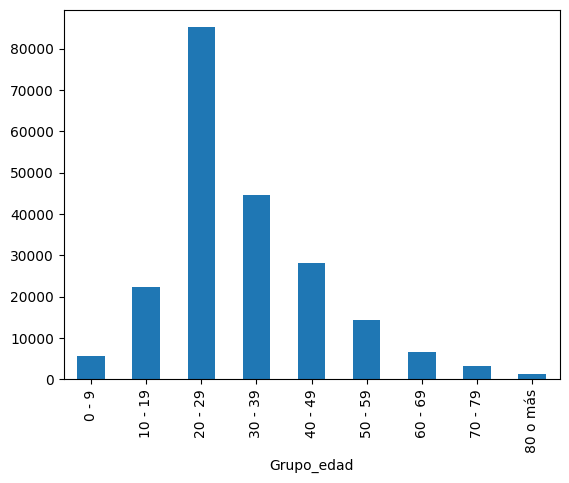

In [105]:
df_2['Grupo_edad'].value_counts(sort=False).plot(kind='bar')

<Axes: xlabel='Dia_semana'>

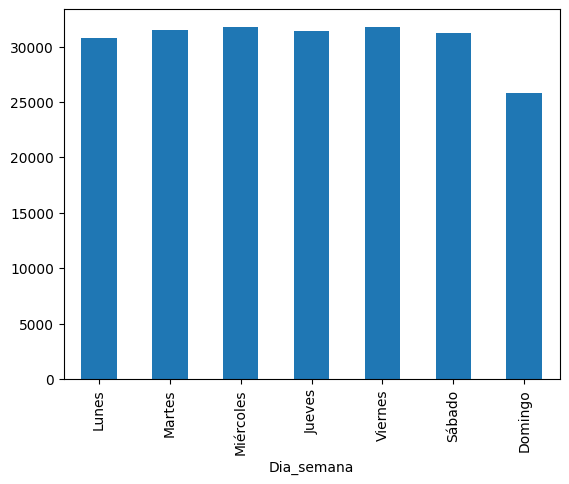

In [106]:
df_2['Dia_semana'].value_counts(sort=False).plot(kind='bar')

<Axes: xlabel='Mes'>

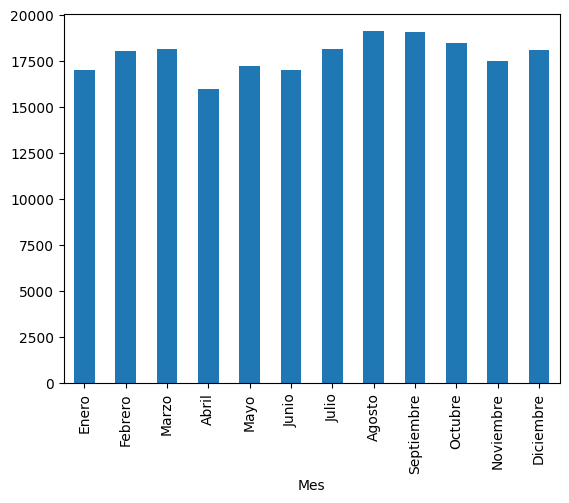

In [107]:
df_2['Mes'].value_counts(sort=False).plot(kind='bar')

# **Cálculo de la mediana**

In [108]:
df_2['Grupo_edad'].cat.categories[df_2['Grupo_edad'].cat.codes.median().astype(int)]

'20 - 29'

In [109]:
df_2['Dia_semana'].cat.categories[df_2['Dia_semana'].cat.codes.median().astype(int)]

'Jueves'

In [110]:
df_2['Mes'].cat.categories[df_2['Mes'].cat.codes.median().astype(int)]

'Julio'

# **Cálculo Cuartiles**

In [111]:
df_2['Grupo_edad'].cat.categories[df_2['Grupo_edad'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index(['20 - 29', '20 - 29', '40 - 49'], dtype='object')

In [112]:
df_2['Dia_semana'].cat.categories[df_2['Dia_semana'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index(['Martes', 'Jueves', 'Sábado'], dtype='object')

In [113]:
df_2['Mes'].cat.categories[df_2['Mes'].cat.codes.quantile([0.25, 0.5, 0.75]).astype(int)]

Index(['Abril', 'Julio', 'Octubre'], dtype='object')